# Actor-Critic (TD(0)) for Pendulum-v1 (Part-2)

## Environment
I implemented an **Actor-Critic algorithm with TD(0)** on the `Pendulum-v1` environment, which has a **continuous action space**. The goal is to learn a policy that applies torque to keep the pendulum upright.

---

## Method Overview

This implementation uses an **online Actor-Critic approach** with **bootstrapping (TD(0))**:

- The **Actor** learns a policy π(a|s)
- The **Critic** estimates the value function V(s)

At each step, we compute the TD error:

δ = r + γ V(s') - V(s)

This TD error is used:
- To train the critic
- As an advantage signal for updating the actor

---

## Actor Network

The actor outputs a **Gaussian policy**:

- Mean: μ(s)
- Standard deviation: σ(s) = exp(log σ)

Actions are:
- Sampled using `dist.sample()`
- Evaluated using `dist.log_prob()`
- Clipped to environment bounds

---

## Critic Network

The critic estimates the value function V(s) and is trained using:

Loss = δ²

---

## Training Updates

- **Critic loss**: δ²  
- **Actor loss**: -log π(a|s) × δ  

We also use **entropy regularization** to encourage exploration.

---

## Hyperparameters

- γ = 0.99  
- Actor LR = 3e-4  
- Critic LR = 1e-3  
- Hidden size = 128  
- Activation = ReLU  
- Initial log std = -0.5  
- Entropy coef = 0.001  
- Episodes = 500  

---

## Goal

Learn a stable continuous control policy and visualize:
- Training performance
- Exploration behavior
- Learned policy

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import Normal

In [2]:
# =========================
# Hyperparameters
# =========================
ENV_NAME = "Pendulum-v1"
GAMMA = 0.99
ACTOR_LR = 3e-4
CRITIC_LR = 1e-3
NUM_EPISODES = 500
HIDDEN_SIZE = 128
INIT_LOG_STD = -0.5
ENTROPY_COEF = 0.001

In [3]:
# =========================
# Environment
# =========================
env = gym.make(ENV_NAME)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_low = float(env.action_space.low[0])
action_high = float(env.action_space.high[0])

In [4]:
# =========================
# Actor Network
# =========================
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
            nn.ReLU()
        )
        self.mu = nn.Linear(HIDDEN_SIZE, action_dim)
        self.log_std = nn.Parameter(torch.ones(action_dim) * INIT_LOG_STD)

    def forward(self, state):
        x = self.net(state)
        mu = self.mu(x)
        std = torch.exp(self.log_std)
        return mu, std

In [5]:
# =========================
# Critic Network
# =========================
class Critic(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, 1)
        )

    def forward(self, state):
        return self.net(state)

In [6]:
# =========================
# Initialize
# =========================
actor = Actor(state_dim, action_dim)
critic = Critic(state_dim)

actor_optimizer = optim.Adam(actor.parameters(), lr=ACTOR_LR)
critic_optimizer = optim.Adam(critic.parameters(), lr=CRITIC_LR)


In [7]:
# =========================
# Training
# =========================
returns = []
entropies = []
td_errors = []

for episode in range(NUM_EPISODES):
    state, _ = env.reset()
    state = torch.tensor(state, dtype=torch.float32)

    done = False
    episode_return = 0
    episode_entropy = 0
    step_count = 0

    while not done:
        mu, std = actor(state)
        dist = Normal(mu, std)

        action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1).mean()

        action_clipped = torch.clamp(action, action_low, action_high)

        next_state, reward, terminated, truncated, _ = env.step(
            action_clipped.detach().numpy()
        )
        done = terminated or truncated

        next_state_tensor = torch.tensor(next_state, dtype=torch.float32)

        V_s = critic(state)
        V_next = critic(next_state_tensor).detach()  # fixed

        delta = reward + GAMMA * V_next * (1 - int(done)) - V_s

        # ---- Critic update ----
        critic_loss = delta.pow(2).mean()
        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()

        # ---- Actor update ----
        actor_loss = -(log_prob * delta.detach()).mean() \
                     - ENTROPY_COEF * entropy  # added entropy reg

        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_optimizer.step()

        state = next_state_tensor
        episode_return += reward
        episode_entropy += entropy.item()
        step_count += 1

        td_errors.append(abs(delta.item()))

    returns.append(episode_return)
    entropies.append(episode_entropy / step_count)  # fixed averaging

    if episode % 50 == 0:
        print(f"Episode {episode}, Return: {episode_return:.2f}")

Episode 0, Return: -1749.22
Episode 50, Return: -1427.25
Episode 100, Return: -1512.74
Episode 150, Return: -1692.88
Episode 200, Return: -1582.39
Episode 250, Return: -1775.44
Episode 300, Return: -1649.74
Episode 350, Return: -1858.88
Episode 400, Return: -1772.00
Episode 450, Return: -1529.97


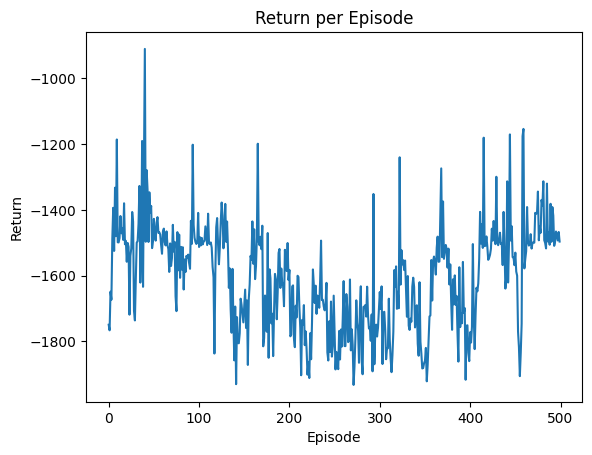

In [8]:
# =========================
# Plot: Returns
# =========================
plt.figure()
plt.plot(returns)
plt.title("Return per Episode")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()

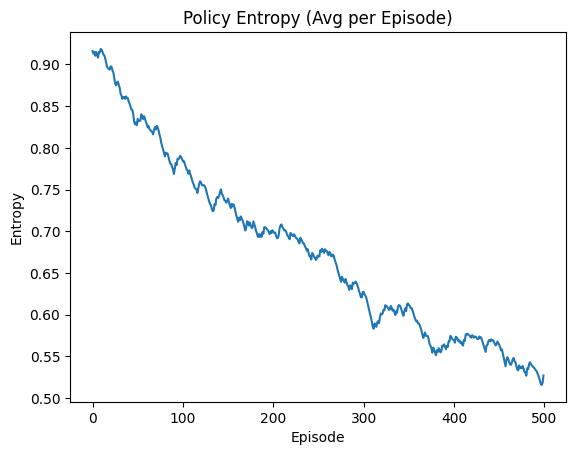

In [9]:
# =========================
# Plot: Entropy
# =========================
plt.figure()
plt.plot(entropies)
plt.title("Policy Entropy (Avg per Episode)")
plt.xlabel("Episode")
plt.ylabel("Entropy")
plt.show()


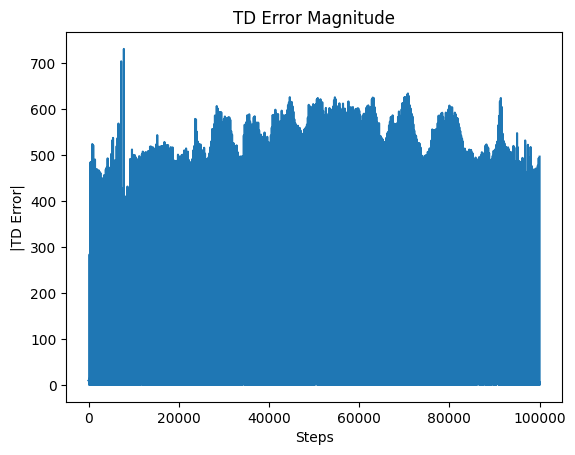

In [10]:
# =========================
# Plot: TD Error
# =========================
plt.figure()
plt.plot(td_errors)
plt.title("TD Error Magnitude")
plt.xlabel("Steps")
plt.ylabel("|TD Error|")
plt.show()

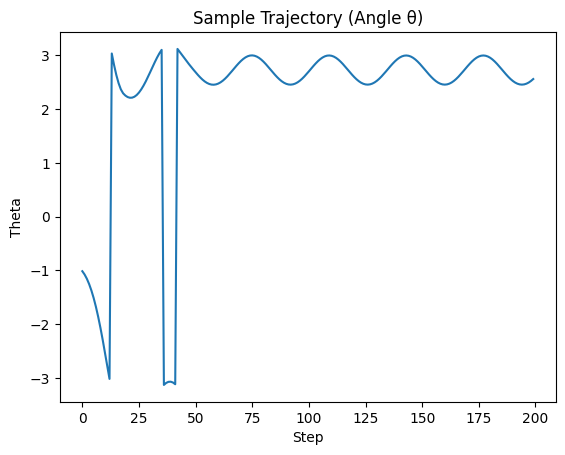

In [11]:
# =========================
# Sample Trajectory (θ)
# =========================
state, _ = env.reset()
state = torch.tensor(state, dtype=torch.float32)

angles = []

for _ in range(200):
    mu, _ = actor(state)
    action = torch.clamp(mu, action_low, action_high)

    next_state, _, done, _, _ = env.step(action.detach().numpy())

    theta = np.arctan2(next_state[1], next_state[0])  # fixed
    angles.append(theta)

    state = torch.tensor(next_state, dtype=torch.float32)

    if done:
        break

plt.figure()
plt.plot(angles)
plt.title("Sample Trajectory (Angle θ)")
plt.xlabel("Step")
plt.ylabel("Theta")
plt.show()

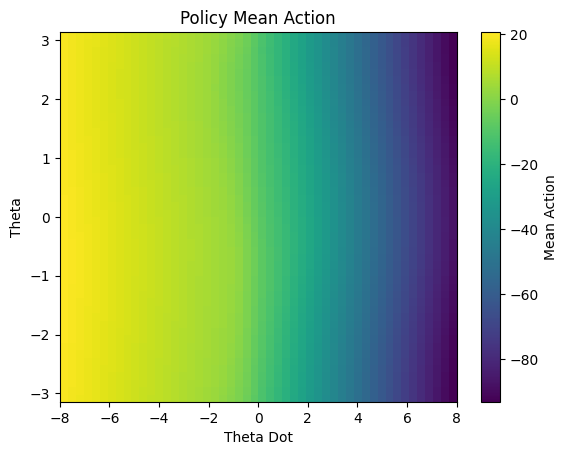

In [ ]:
# =========================
# Policy Visualization 
# =========================
theta_vals = np.linspace(-np.pi, np.pi, 50)
theta_dot_vals = np.linspace(-8, 8, 50)

policy_grid = []

for theta in theta_vals:
    row = []
    for theta_dot in theta_dot_vals:
        state = torch.tensor(
            [np.cos(theta), np.sin(theta), theta_dot],
            dtype=torch.float32
        )
        mu, _ = actor(state)
        row.append(mu.item())
    policy_grid.append(row)

plt.figure()
plt.imshow(policy_grid,
           extent=[-8, 8, -np.pi, np.pi],
           aspect='auto',
           origin='lower')
plt.colorbar(label="Mean Action")
plt.xlabel("Theta Dot")
plt.ylabel("Theta")
plt.title("Policy Mean Action")
plt.show()

In [13]:
# =========================
# Save Models
# =========================
torch.save(actor.state_dict(), "actor.pth")
torch.save(critic.state_dict(), "critic.pth")